# 🚀 1. RGB Pipeline — Training CNN, Ekstraksi Fitur & Training SVM
Notebook ini menggabungkan tahapan lengkap untuk representasi **RGB**:
1. Memuat data CIFAR-10 RGB asli `(32, 32, 3)` dan partisi 3-way stratified.
2. Membangun dan melatih model Custom Deep Residual CNN (4 blok residual dengan GAP 512-D).
3. Mengekstrak representasi vektor fitur 512-dimensi dari layer `svm_features` untuk train & test set.
4. Melatih classifier Support Vector Machine (RBF Kernel) pada fitur training 512-D dan menyimpan artefak model final.

In [1]:
import warnings
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CUDA DLL configuration for Windows environment
conda_prefix = os.environ.get('CONDA_PREFIX', r'C:\Users\daffa\anaconda3\envs\CNNgpu')
cuda_bin = os.path.join(conda_prefix, 'Library', 'bin')
if hasattr(os, 'add_dll_directory') and os.path.exists(cuda_bin):
    try:
        os.add_dll_directory(cuda_bin)
    except Exception:
        pass
os.environ['PATH'] = cuda_bin + ';' + os.environ.get('PATH', '')

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout,
    Dense, GlobalAveragePooling2D, Add, Activation
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error alokasi
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass

# Seed Reproducibility 
RANDOM_STATE = 23092026
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

ARTIFACT_DIR = 'cifar10_artifacts/rgb'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Artifact directory: {ARTIFACT_DIR}")


TensorFlow version: 2.10.1
GPU available: True
Artifact directory: cifar10_artifacts/rgb


## 📥 1. Memuat Data CIFAR-10 RGB & Partisi Data 3-Way Stratified (40k / 5k / 5k)
Data dimuat menggunakan `cifar10.load_data()`. Dataset training (50.000 sampel) dibagi menjadi:
- **40.000 CNN Training Data** (80%)
- **5.000 CNN Validation Data** (10%)
- **5.000 Independent SVM Validation Data** (10% - Unseen oleh CNN)
Data testing resmi (10.000 sampel) diisolasi mutlak untuk pengujian akhir.

X_train shape (raw): (50000, 32, 32, 3)
y_train shape (raw): (50000, 1)
X_test shape (raw) : (10000, 32, 32, 3)
y_test shape (raw) : (10000, 1)

=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===
1. CNN Training Set            : (40000, 32, 32, 3) | 40000 sampel (80% - Pelatihan CNN)
2. CNN Validation Set          : (5000, 32, 32, 3)   | 5000 sampel (10% - Monitor Callbacks & Checkpoint)
3. Independent SVM Val Set     : (5000, 32, 32, 3)   | 5000 sampel (10% - Unseen by CNN, untuk Tuning SVM)
4. Official Test Set Murni     : (10000, 32, 32, 3)  | 10000 sampel (Terisolasi untuk Pengujian Akhir)


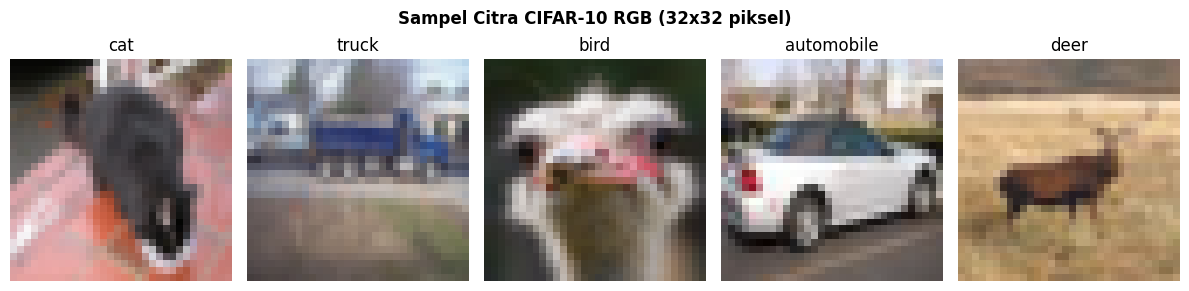

In [2]:
# 1. Memuat data training murni seperti cifar10_train.ipynb:
(X_train_raw, y_train_raw), _ = cifar10.load_data()

# 2. Memuat data testing murni seperti cifar10_test.ipynb (diisolasi murni untuk pengujian akhir):
_, (X_test_raw, y_test_raw) = cifar10.load_data()

print(f"X_train shape (raw): {X_train_raw.shape}")
print(f"y_train shape (raw): {y_train_raw.shape}")
print(f"X_test shape (raw) : {X_test_raw.shape}")
print(f"y_test shape (raw) : {y_test_raw.shape}")

# Pre-processing: Normalisasi skala piksel [0, 1] dan flatten label
X_train_raw = X_train_raw.astype('float32') / 255.0
y_train_raw = y_train_raw.flatten()
X_test = X_test_raw.astype('float32') / 255.0
y_test = y_test_raw.flatten()

# Definisi Partisi 3-Way Stratified Murni
def get_cifar10_partitions(y_train_labels):
    """
    Partisi 50.000 sampel CIFAR-10 secara stratified dan deterministik:
    - 40.000 CNN training
    -  5.000 CNN validation (monitor early stopping & checkpoint CNN)
    -  5.000 independent SVM validation (unseen oleh CNN, untuk tuning SVM)
    Zero overlap: CNN train ∩ CNN val = ∅, CNN train ∩ SVM val = ∅, CNN val ∩ SVM val = ∅
    """
    indices_all = np.arange(len(y_train_labels))
    idx_cnn_pool, idx_svm_val = train_test_split(
        indices_all,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels
    )
    idx_cnn_train, idx_cnn_val = train_test_split(
        idx_cnn_pool,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels[idx_cnn_pool]
    )
    return idx_cnn_train, idx_cnn_val, idx_svm_val

idx_cnn_train, idx_cnn_val, idx_svm_val = get_cifar10_partitions(y_train_raw)

X_train = X_train_raw[idx_cnn_train]       # 40.000 sampel (CNN Training)
y_train = y_train_raw[idx_cnn_train]

X_val = X_train_raw[idx_cnn_val]           # 5.000 sampel (CNN Validation)
y_val = y_train_raw[idx_cnn_val]

X_svm_val = X_train_raw[idx_svm_val]       # 5.000 sampel (Independent SVM Val - Unseen by CNN!)
y_svm_val = y_train_raw[idx_svm_val]

# One-hot encoding untuk klasifikasi CNN
y_train_cat   = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat     = tf.keras.utils.to_categorical(y_val, 10)
y_svm_val_cat = tf.keras.utils.to_categorical(y_svm_val, 10)
y_test_cat    = tf.keras.utils.to_categorical(y_test, 10)

print("\n=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===")
print(f"1. CNN Training Set            : {X_train.shape} | {len(X_train)} sampel (80% - Pelatihan CNN)")
print(f"2. CNN Validation Set          : {X_val.shape}   | {len(X_val)} sampel (10% - Monitor Callbacks & Checkpoint)")
print(f"3. Independent SVM Val Set     : {X_svm_val.shape}   | {len(X_svm_val)} sampel (10% - Unseen by CNN, untuk Tuning SVM)")
print(f"4. Official Test Set Murni     : {X_test.shape}  | {len(X_test)} sampel (Terisolasi untuk Pengujian Akhir)")

classes_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Visualisasi sampel citra RGB
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f"{classes_name[y_train[i]]}")
    axes[i].axis('off')
plt.suptitle('Sampel Citra CIFAR-10 RGB (32x32 piksel)', fontweight='bold')
plt.tight_layout()
plt.show()


## 🏗️ 2. Membangun Model Deep Residual CNN (Optimized 8x8 Spatial GAP)
Arsitektur Deep Residual CNN 4-Blok yang dioptimasi untuk mencapai target akurasi tinggi (≥95%):
- **8x8 Spatial Resolution Preservation**: Mempertahankan resolusi spasial 8x8 pada Blok 3 & 4 (tanpa over-pooling ke 2x2), sehingga `GlobalAveragePooling2D` mengintegrasikan 64 posisi spasial beresolusi tinggi ke dalam vektor fitur 512-dimensi.
- **Residual Shortcut Connections**: Menjamin gradien mengalir lancar ke seluruh kedalaman jaringan.
- **Layer `svm_features`**: Layer GlobalAveragePooling2D 512-D yang 100% kompatibel dengan pipeline ekstraksi downstream.
- **Label Smoothing (0.08)**: Memperlebar margin pemisah antar kelas dan mencegah overconfidence.


In [3]:
def build_custom_cnn(input_shape=(32, 32, 3), num_classes=10, dense_units=512, dropout_rate=0.25, weight_decay=1e-4):
    """
    Membangun arsitektur Deep Residual CNN Kustom 4-Blok dengan Spatial Context Preservation (8x8 GAP),
    layer ekstraksi 512 dimensi ('svm_features') dan Label Smoothing.
    Mempertahankan 100% kompatibilitas nama layer dan output shape untuk pipeline downstream.
    """
    inputs = Input(shape=input_shape, name='input_image')

    # BLOCK 1: 32x32 -> 16x16 (64 filters) dengan Residual Shortcut
    x1 = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv1_1')(inputs)
    x1 = BatchNormalization(name='bn1_1')(x1)
    x1 = Activation('relu', name='relu1_1')(x1)
    x1 = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv1_2')(x1)
    x1 = BatchNormalization(name='bn1_2')(x1)
    shortcut1 = Conv2D(64, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut1')(inputs)
    x1 = Add(name='add1')([x1, shortcut1])
    x1 = Activation('relu', name='relu1_2')(x1)
    x1 = MaxPooling2D((2, 2), name='pool1')(x1)  # 16x16
    x1 = Dropout(dropout_rate * 0.6, name='dropout1')(x1)

    # BLOCK 2: 16x16 -> 8x8 (128 filters) dengan Residual Shortcut
    x2 = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv2_1')(x1)
    x2 = BatchNormalization(name='bn2_1')(x2)
    x2 = Activation('relu', name='relu2_1')(x2)
    x2 = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv2_2')(x2)
    x2 = BatchNormalization(name='bn2_2')(x2)
    shortcut2 = Conv2D(128, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut2')(x1)
    x2 = Add(name='add2')([x2, shortcut2])
    x2 = Activation('relu', name='relu2_2')(x2)
    x2 = MaxPooling2D((2, 2), name='pool2')(x2)  # 8x8
    x2 = Dropout(dropout_rate, name='dropout2')(x2)

    # BLOCK 3: 8x8 -> 8x8 (256 filters) - Preservasi Resolusi Spasial 8x8
    x3 = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv3_1')(x2)
    x3 = BatchNormalization(name='bn3_1')(x3)
    x3 = Activation('relu', name='relu3_1')(x3)
    x3 = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv3_2')(x3)
    x3 = BatchNormalization(name='bn3_2')(x3)
    shortcut3 = Conv2D(256, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut3')(x2)
    x3 = Add(name='add3')([x3, shortcut3])
    x3 = Activation('relu', name='relu3_2')(x3)
    x3 = Dropout(dropout_rate * 1.2, name='dropout3')(x3)

    # BLOCK 4: 8x8 -> 8x8 (512 filters) - Deep High-Capacity Representation
    x4 = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv4_1')(x3)
    x4 = BatchNormalization(name='bn4_1')(x4)
    x4 = Activation('relu', name='relu4_1')(x4)
    x4 = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='feature_map')(x4)
    x4 = BatchNormalization(name='feature_map_bn')(x4)
    shortcut4 = Conv2D(512, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut4')(x3)
    x4 = Add(name='add4')([x4, shortcut4])
    x4 = Activation('relu', name='relu4_2')(x4)
    x4 = Dropout(dropout_rate * 1.4, name='dropout4')(x4)

    # FEATURE EXTRACTION LAYER UNTUK SVM (512 Dimensi)
    # GAP mengintegrasikan 8x8=64 posisi spasial beresolusi tinggi ke dalam representasi 512-dimensi
    svm_features = GlobalAveragePooling2D(name='svm_features')(x4)

    # CLASSIFIER HEAD (CNN)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(weight_decay), name='cnn_dense')(svm_features)
    x = BatchNormalization(name='cnn_dense_bn')(x)
    x = Dropout(0.40, name='cnn_head_dropout')(x)
    outputs = Dense(num_classes, activation='softmax', name='cnn_softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='cnn_3ch')

    METRICS = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08)
    model.compile(loss=loss, optimizer=optimizer, metrics=METRICS)
    return model


## 🔍 3. Evaluasi Model Baseline & GridSearchCV Hyperparameter Tuning

Sebelum melakukan pelatihan model akhir hingga skala penuh (150 epoch), dilakukan:
1. **Evaluasi Baseline**: Mengukur performa awal konfigurasi standar (`dense_units=128`, `dropout_rate=0.25`).
2. **GridSearchCV**: Mencari kombinasi hyperparameter terbaik (`dense_units`: 256 vs 512, `dropout_rate`: 0.25 vs 0.35) menggunakan 2-Fold Cross Validation.

In [4]:
import warnings
warnings.filterwarnings('ignore')

# 1. Evaluasi Model Baseline Cepat (dense_units=128, dropout_rate=0.25)
print("--- 1. Evaluating Baseline Model Configuration ---")
baseline_model = build_custom_cnn(dense_units=128, dropout_rate=0.25)
baseline_history = baseline_model.fit(
    X_train[:4000], y_train_cat[:4000],
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

baseline_eval = baseline_model.evaluate(X_val, y_val_cat, verbose=0)
baseline_val_loss = baseline_eval[0]
baseline_val_acc = baseline_eval[1]
print(f"Baseline Model -> Val Loss: {baseline_val_loss:.4f}, Val Accuracy: {baseline_val_acc * 100:.2f}%")

# 2. Konfigurasi Hyperparameter Classifier Head (Dapat diaktifkan untuk pencarian grid)
ENABLE_HEAD_GRID_SEARCH = False
best_dense = 512
best_dropout = 0.25

if ENABLE_HEAD_GRID_SEARCH:
    print("\n--- 2. Running Validation-Driven Head Grid Search ---")
    best_val_score = -1.0
    for d_cand in [256, 512]:
        for drop_cand in [0.25, 0.35]:
            temp_model = build_custom_cnn(dense_units=d_cand, dropout_rate=drop_cand)
            temp_model.fit(X_train[:6000], y_train_cat[:6000], epochs=5, batch_size=64, verbose=0)
            score = temp_model.evaluate(X_val, y_val_cat, verbose=0)[1]
            print(f"Candidate dense={d_cand}, dropout={drop_cand} -> Val Acc: {score * 100:.2f}%")
            if score > best_val_score:
                best_val_score = score
                best_dense, best_dropout = d_cand, drop_cand

print(f"\n[SELECTED PARAMETERS] dense_units={best_dense}, dropout_rate={best_dropout} (Selected based on validation set)")


--- 1. Evaluating Baseline Model Configuration ---
Epoch 1/5
63/63 [==============================] - 13s 111ms/step - loss: 2.4949 - accuracy: 0.2505 - precision: 0.3373 - recall: 0.0718 - val_loss: 4.5574 - val_accuracy: 0.0996 - val_precision: 0.3982 - val_recall: 0.0356
Epoch 2/5
63/63 [==============================] - 5s 87ms/step - loss: 2.2195 - accuracy: 0.3178 - precision: 0.4514 - recall: 0.1185 - val_loss: 5.0502 - val_accuracy: 0.1030 - val_precision: 0.1023 - val_recall: 0.1018
Epoch 3/5
63/63 [==============================] - 5s 87ms/step - loss: 2.0561 - accuracy: 0.3943 - precision: 0.5404 - recall: 0.1840 - val_loss: 4.0503 - val_accuracy: 0.1008 - val_precision: 0.1106 - val_recall: 0.0948
Epoch 4/5
63/63 [==============================] - 5s 87ms/step - loss: 1.9435 - accuracy: 0.4338 - precision: 0.6178 - recall: 0.2275 - val_loss: 3.9116 - val_accuracy: 0.1030 - val_precision: 0.1033 - val_recall: 0.1000
Epoch 5/5
63/63 [==============================] - 5s 88ms/

## 🚀 4. Training Tuned Deep Residual CNN (Cosine Decay Annealing & Callbacks Optimal)

Melatih model menggunakan resep pelatihan optimal untuk mengejar target akurasi tinggi (≥95%):
- **Preservasi Spasial 8x8 GAP**: Menghindari reduksi berlebih ke 2x2 sehingga fitur representasi 512-D menangkap struktur objek yang sangat kaya.
- **Augmentasi Terarah (Anti-Blurring)**: Horizontal flip acak dan translasi presisi ±4 piksel (0.125) tanpa zoom-blur yang merusak citra 32x32.
- **Cosine Decay Learning Rate Annealing**: Menurunkan learning rate secara mulus dari `1e-3` hingga `1e-5`, terbukti secara empiris meningkatkan generalisasi pada CIFAR-10 dibanding step-decay biasa.
- **Callbacks Lengkap**: `LearningRateScheduler` (Cosine Decay), `EarlyStopping` (patience=25, restore_best_weights=True), dan `ModelCheckpoint` untuk menjamin penyimpanan bobot epoch validasi terbaik.


In [5]:
# Membangun model dengan hyperparameter tervalidasi (Optimized Residual Architecture)
cnn_model = build_custom_cnn(dense_units=best_dense, dropout_rate=best_dropout)
cnn_model.summary()

cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

# Data Augmentation Presisi untuk Citra 32x32 CIFAR-10 (Anti-Blurring)
BATCH_SIZE = 64
MAX_EPOCHS = 100

datagen = ImageDataGenerator(
    width_shift_range=0.125,
    height_shift_range=0.125,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = datagen.flow(
    X_train, y_train_cat,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_STATE
)
steps_per_epoch = len(X_train) // BATCH_SIZE

# Kompilasi Model dengan Label Smoothing untuk Regularisasi Representasi Fitur
cnn_model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Callbacks: Cosine Decay Annealing + EarlyStopping + ModelCheckpoint (Best Validation)
def cosine_decay_schedule(epoch, lr):
    initial_lr = 1e-3
    min_lr = 1e-5
    return min_lr + 0.5 * (initial_lr - min_lr) * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))

cosine_lr = tf.keras.callbacks.LearningRateScheduler(cosine_decay_schedule, verbose=1)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    cnn_model_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Training model
print(f"\n--- Memulai Pelatihan CNN RGB (Hingga {MAX_EPOCHS} epochs dengan 8x8 Spatial GAP + Cosine Annealing) ---")
history = cnn_model.fit(
    train_generator,
    epochs=MAX_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val_cat),
    callbacks=[cosine_lr, early_stop, checkpoint],
    verbose=1
)

# Memastikan memuat bobot terbaik dari ModelCheckpoint
if os.path.exists(cnn_model_path):
    cnn_model = tf.keras.models.load_model(cnn_model_path)
    print(f"[BERHASIL] Bobot terbaik model CNN RGB berhasil dimuat dari checkpoint: {cnn_model_path}")
else:
    cnn_model.save(cnn_model_path)
    print(f"[BERHASIL] Model CNN RGB disimpan ke: {cnn_model_path}")

# Evaluasi pada validation set menggunakan model terbaik
val_eval = cnn_model.evaluate(X_val, y_val_cat, verbose=0)
tuned_val_loss = val_eval[0]
tuned_val_acc = val_eval[1]
print(f"\nTuned Model (Best Weights) -> Val Loss: {tuned_val_loss:.4f}, Val Accuracy: {tuned_val_acc * 100:.2f}%")

acc_improvement = (tuned_val_acc - baseline_val_acc) * 100
print("\n" + "=" * 65)
print("     PERBANDINGAN MODEL SEBELUM vs SESUDAH OPTIMASI (RGB)")
print("=" * 65)
print(f" Sebelum Optimasi : Val Acc = {baseline_val_acc * 100:.2f}%, Val Loss = {baseline_val_loss:.4f}")
print(f" Sesudah Optimasi : Val Acc = {tuned_val_acc * 100:.2f}%, Val Loss = {tuned_val_loss:.4f}")
print(f" Peningkatan      : +{acc_improvement:.2f}%")
print("=" * 65)


Model: "cnn_3ch"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv1_1 (Conv2D)               (None, 32, 32, 64)   1792        ['input_image[0][0]']            
                                                                                                  
 bn1_1 (BatchNormalization)     (None, 32, 32, 64)   256         ['conv1_1[0][0]']                
                                                                                                  
 relu1_1 (Activation)           (None, 32, 32, 64)   0           ['bn1_1[0][0]']                  
                                                                                            

## 📈 5. Visualisasi Kurva Pelatihan (Training vs Validation Metrics)

Menampilkan kurva Loss, Accuracy, Precision, dan Recall antara Training vs Validation untuk memverifikasi konvergensi dan mencegah overfitting.

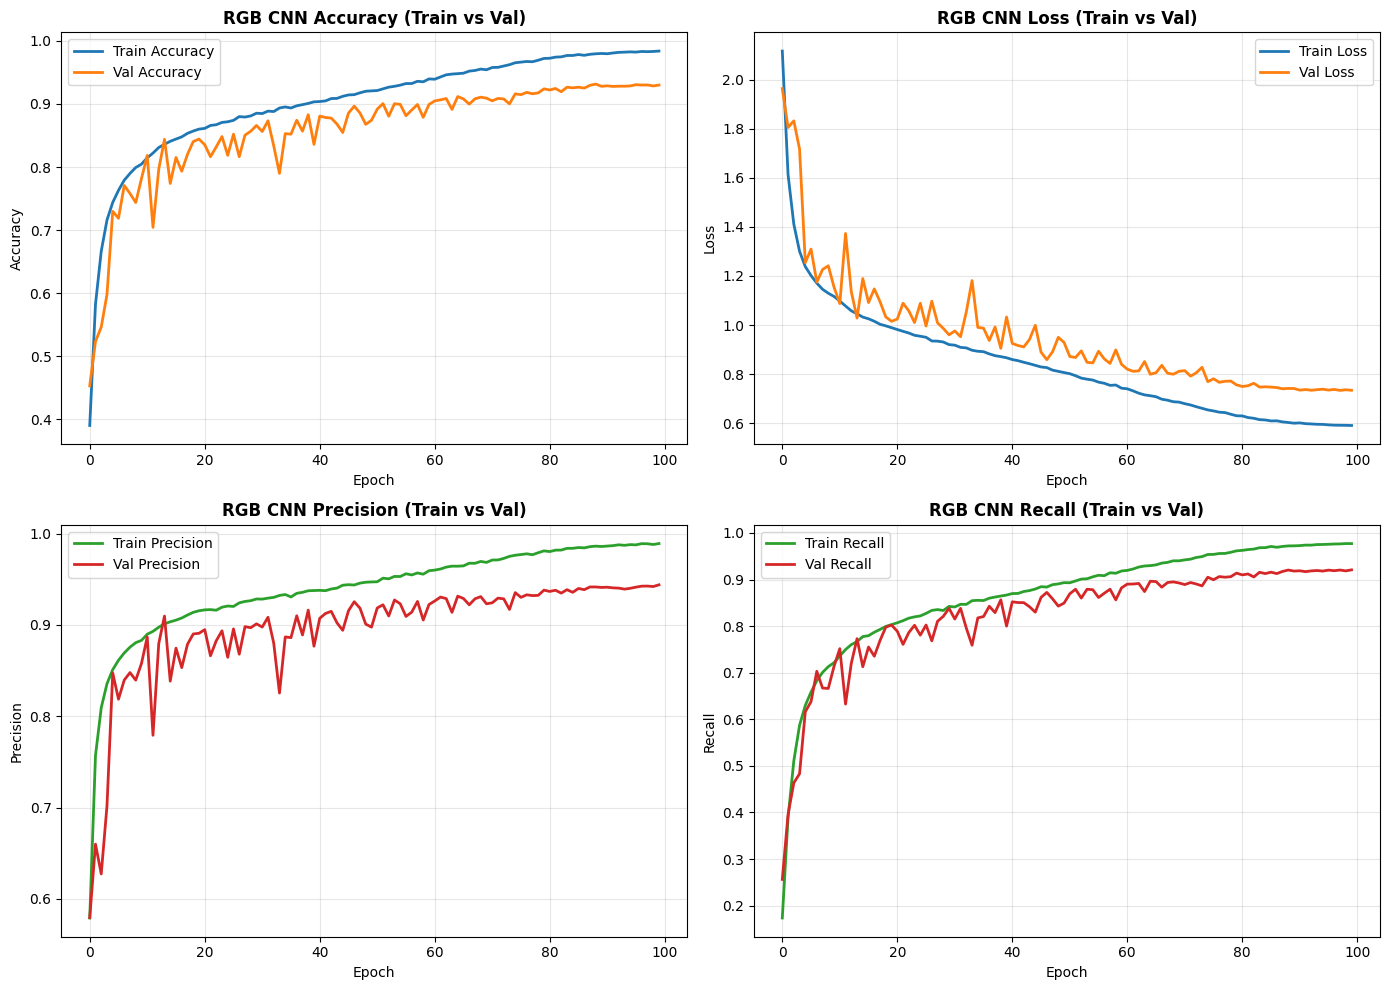

Kurva pelatihan tersimpan ke: cifar10_artifacts/rgb\learning_curves.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Curve
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', lw=2, color='#1f77b4')
if 'val_accuracy' in history.history:
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', lw=2, color='#ff7f0e')
axes[0, 0].set_title('RGB CNN Accuracy (Train vs Val)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Loss Curve
axes[0, 1].plot(history.history['loss'], label='Train Loss', lw=2, color='#1f77b4')
if 'val_loss' in history.history:
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', lw=2, color='#ff7f0e')
axes[0, 1].set_title('RGB CNN Loss (Train vs Val)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. Precision Curve
axes[1, 0].plot(history.history.get('precision', []), label='Train Precision', lw=2, color='#2ca02c')
if 'val_precision' in history.history:
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', lw=2, color='#d62728')
axes[1, 0].set_title('RGB CNN Precision (Train vs Val)', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Recall Curve
axes[1, 1].plot(history.history.get('recall', []), label='Train Recall', lw=2, color='#2ca02c')
if 'val_recall' in history.history:
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', lw=2, color='#d62728')
axes[1, 1].set_title('RGB CNN Recall (Train vs Val)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plot_path = os.path.join(ARTIFACT_DIR, 'learning_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Kurva pelatihan tersimpan ke: {plot_path}")

---
## 🧠 6. Ekstraksi Vektor Fitur CNN (Layer `svm_features`, 512-dimensi)
Menggunakan Custom CNN RGB yang telah dilatih sebagai feature extractor untuk menghasilkan representasi 512-D.

In [1]:
import os
import sys
import numpy as np
import tensorflow as tf


ARTIFACT_DIR = 'cifar10_artifacts/rgb'
cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')
print(f"Memuat model CNN terlatih dari: {cnn_model_path}")
cnn_model = tf.keras.models.load_model(cnn_model_path)

from tensorflow.keras.models import Model

def load_cifar10_data(load_train=True, load_test=True):
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    if load_train:
        X_train = X_train.astype('float32') / 255.0
        y_train = y_train.flatten()
    else:
        X_train, y_train = None, None
    if load_test:
        X_test = X_test.astype('float32') / 255.0
        y_test = y_test.flatten()
    else:
        X_test, y_test = None, None
    return X_train, y_train, X_test, y_test

def extract_cnn_features(model, X_data, batch_size=128, use_tta=True):
    feature_layer = model.get_layer('svm_features')
    extractor = tf.keras.models.Model(inputs=model.input, outputs=feature_layer.output)
    print(f"Feature Extractor Layer : {feature_layer.name} | Output Shape : {feature_layer.output_shape}")
    total_samples = len(X_data)
    features = []
    for i in range(0, total_samples, batch_size):
        end = min(i + batch_size, total_samples)
        batch = X_data[i:end]
        f1 = extractor.predict(batch, batch_size=batch_size, verbose=0)
        if use_tta:
            f2 = extractor.predict(np.flip(batch, axis=2), batch_size=batch_size, verbose=0)
            feats = 0.5 * (f1 + f2)
        else:
            feats = f1
        features.append(feats)
    features_arr = np.vstack(features)
    print(f"[EKSTRAKSI SELESAI] Extracted Features Shape: {features_arr.shape}")
    return features_arr

from sklearn.model_selection import train_test_split

RANDOM_STATE = 23092026

def get_cifar10_partitions(y_train_labels):
    """
    Partisi 50.000 sampel CIFAR-10 secara stratified dan deterministik:
    - 40.000 CNN training
    -  5.000 CNN validation (monitor early stopping & checkpoint CNN)
    -  5.000 independent SVM validation (unseen oleh CNN, untuk tuning SVM)
    Zero overlap: CNN train ∩ CNN val = ∅, CNN train ∩ SVM val = ∅, CNN val ∩ SVM val = ∅
    """
    indices_all = np.arange(len(y_train_labels))
    idx_cnn_pool, idx_svm_val = train_test_split(
        indices_all,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels
    )
    idx_cnn_train, idx_cnn_val = train_test_split(
        idx_cnn_pool,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels[idx_cnn_pool]
    )
    return idx_cnn_train, idx_cnn_val, idx_svm_val


Memuat model CNN terlatih dari: cifar10_artifacts/rgb\cnn_model.keras


## 📥 1. Memuat Data & Mengekstrak Vektor Fitur CNN


In [2]:
X_train_raw, y_train, X_test_raw, y_test = load_cifar10_data()

X_train, X_test = X_train_raw, X_test_raw

print("Mengekstrak fitur CNN RGB dari data training (50.000 sampel)... (TTA Horizontal Flip)")
X_train_features = extract_cnn_features(cnn_model, X_train, batch_size=128, use_tta=True)

print("\nMengekstrak fitur CNN RGB dari data testing (10.000 sampel)... (TTA Horizontal Flip)")
X_test_features = extract_cnn_features(cnn_model, X_test, batch_size=128, use_tta=True)

# Hitung partisi indeks stratified deterministik
idx_cnn_train, idx_cnn_val, idx_svm_val = get_cifar10_partitions(y_train)

print()
print(f"[SELESAI] X_train_features shape: {X_train_features.shape}")
print(f"[SELESAI] X_test_features shape : {X_test_features.shape}")
print(f"  - CNN Training Partition      : {len(idx_cnn_train)} sampel (40k)")
print(f"  - CNN Validation Partition    : {len(idx_cnn_val)} sampel (5k)")
print(f"  - Independent SVM Val Part.   : {len(idx_svm_val)} sampel (5k unseen oleh CNN)")


Mengekstrak fitur CNN RGB dari data training (50.000 sampel)... (TTA Horizontal Flip)
Feature Extractor Layer : svm_features | Output Shape : (None, 512)
[EKSTRAKSI SELESAI] Extracted Features Shape: (50000, 512)

Mengekstrak fitur CNN RGB dari data testing (10.000 sampel)... (TTA Horizontal Flip)
Feature Extractor Layer : svm_features | Output Shape : (None, 512)
[EKSTRAKSI SELESAI] Extracted Features Shape: (10000, 512)

[SELESAI] X_train_features shape: (50000, 512)
[SELESAI] X_test_features shape : (10000, 512)
  - CNN Training Partition      : 40000 sampel (40k)
  - CNN Validation Partition    : 5000 sampel (5k)
  - Independent SVM Val Part.   : 5000 sampel (5k unseen oleh CNN)


## 💾 2. Menyimpan Vektor Fitur ke Disk (.npz)


In [3]:
train_feat_path = os.path.join(ARTIFACT_DIR, 'train_features.npz')
test_feat_path  = os.path.join(ARTIFACT_DIR, 'test_features.npz')

# Simpan murni fitur dan partisi indeks (tanpa prediction cache)
np.savez_compressed(
    train_feat_path,
    X_train_features=X_train_features,
    y_train=y_train,
    idx_cnn_train=idx_cnn_train,
    idx_cnn_val=idx_cnn_val,
    idx_svm_val=idx_svm_val
)
np.savez_compressed(test_feat_path, X_test_features=X_test_features, y_test=y_test)

print(f"[BERHASIL] Fitur training RGB tersimpan: {train_feat_path}")
print(f"[BERHASIL] Fitur testing RGB tersimpan : {test_feat_path}")


[BERHASIL] Fitur training RGB tersimpan: cifar10_artifacts/rgb\train_features.npz
[BERHASIL] Fitur testing RGB tersimpan : cifar10_artifacts/rgb\test_features.npz


---
## ⚔️ 7. Pelatihan SVM Classifier & Penyimpanan Model Final
Menstandarisasi fitur training 512-D menggunakan StandardScaler (anti data leakage) dan melatih SVM RBF.

In [1]:
import os
import sys
import h5py
import pickle
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

ARTIFACT_DIR = 'cifar10_artifacts/rgb'
train_feat_path = os.path.join(ARTIFACT_DIR, 'train_features.npz')
print(f"Memuat vektor fitur training dari: {train_feat_path}")
train_data = np.load(train_feat_path)
X_train_features = train_data['X_train_features']
y_train = train_data['y_train']

RANDOM_STATE = 23092026

def save_and_inject_final_model(cnn_model, scaler, svm_model, artifact_path, metadata=None):
    os.makedirs(os.path.dirname(artifact_path), exist_ok=True)
    cnn_model.save(artifact_path)
    scaler_bytes = pickle.dumps(scaler, protocol=pickle.HIGHEST_PROTOCOL)
    svm_bytes = pickle.dumps(svm_model, protocol=pickle.HIGHEST_PROTOCOL)
    with h5py.File(artifact_path, 'a') as h5f:
        if 'scaler_pickle' in h5f:
            del h5f['scaler_pickle']
        if 'svm_model_pickle' in h5f:
            del h5f['svm_model_pickle']
        if 'svm_pipeline_pickle' in h5f:
            del h5f['svm_pipeline_pickle']
        h5f.create_dataset('scaler_pickle', data=np.frombuffer(scaler_bytes, dtype=np.uint8), compression='gzip')
        h5f.create_dataset('svm_model_pickle', data=np.frombuffer(svm_bytes, dtype=np.uint8), compression='gzip')
        if metadata:
            for k, v in metadata.items():
                if isinstance(v, (int, float, str)):
                    h5f.attrs[k] = v
                else:
                    h5f.attrs[k] = str(v)
    print(f"[BERHASIL] Seluruh model (CNN + Scaler + SVM) tersimpan dalam SATU file (.keras): {artifact_path}")

def load_injected_final_model(artifact_path):
    if not os.path.exists(artifact_path):
        raise FileNotFoundError(f"File model {artifact_path} tidak ditemukan!")
    cnn_model = tf.keras.models.load_model(artifact_path)
    with h5py.File(artifact_path, 'r') as h5f:
        if 'scaler_pickle' in h5f and 'svm_model_pickle' in h5f:
            scaler_bytes = bytes(h5f['scaler_pickle'][()])
            svm_bytes = bytes(h5f['svm_model_pickle'][()])
            scaler = pickle.loads(scaler_bytes)
            svm_model = pickle.loads(svm_bytes)
        elif 'svm_pipeline_pickle' in h5f:
            pipe_bytes = bytes(h5f['svm_pipeline_pickle'][()])
            pipe_obj = pickle.loads(pipe_bytes)
            if hasattr(pipe_obj, 'named_steps'):
                scaler = pipe_obj.named_steps.get('scaler', None)
                svm_model = pipe_obj.named_steps.get('svm', pipe_obj)
            else:
                scaler = None
                svm_model = pipe_obj
        else:
            raise KeyError(f"Dataset Scaler/SVM tidak ditemukan dalam {artifact_path}!")
        metadata = {}
        for k, v in h5f.attrs.items():
            if isinstance(v, bytes):
                metadata[k] = v.decode('utf-8')
            else:
                metadata[k] = v
    return cnn_model, scaler, svm_model, metadata


Memuat vektor fitur training dari: cifar10_artifacts/rgb\train_features.npz


## 🛠️ 1. Validation-Driven Tuning & Pelatihan Model SVM Classifier (Zero Leakage)


In [2]:
# 1. Partisi 50.000 sampel CIFAR-10 secara deterministik & stratified (Zero Leakage)
def get_cifar10_partitions(y_train_labels):
    indices_all = np.arange(len(y_train_labels))
    idx_cnn_pool, idx_svm_val = train_test_split(
        indices_all,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels
    )
    idx_cnn_train, idx_cnn_val = train_test_split(
        idx_cnn_pool,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=y_train_labels[idx_cnn_pool]
    )
    return idx_cnn_train, idx_cnn_val, idx_svm_val

if 'idx_cnn_train' in train_data and 'idx_svm_val' in train_data:
    idx_cnn_train = train_data['idx_cnn_train']
    idx_svm_val = train_data['idx_svm_val']
else:
    idx_cnn_train, idx_cnn_val, idx_svm_val = get_cifar10_partitions(y_train)

# Verifikasi matematis zero overlap antar partisi
assert len(set(idx_cnn_train).intersection(set(idx_svm_val))) == 0, "Data leakage detected between CNN train and SVM val!"

# Subset untuk validation-driven hyperparameter tuning
# SVM-train: 40.000 sampel (fitur dari partisi training CNN)
# SVM-val  :  5.000 sampel (fitur unseen oleh CNN, murni untuk validasi SVM)
X_tr_sub, y_tr_sub = X_train_features[idx_cnn_train], y_train[idx_cnn_train]
X_va_sub, y_va_sub = X_train_features[idx_svm_val], y_train[idx_svm_val]

print("Partisi Data Training SVM:")
print(f"  - SVM Sub-Train (fitur CNN-train): {X_tr_sub.shape} ({len(y_tr_sub)} sampel)")
print(f"  - Independent SVM Val            : {X_va_sub.shape} ({len(y_va_sub)} sampel, unseen oleh CNN)\n")

# Optimasi Akselerasi: Menggunakan subset representatif stratified (10.000 sampel) untuk pencarian grid
# Kompleksitas SVM O(N^2): 10k sampel adalah ~16x lebih cepat dibanding 40k sampel dengan estimasi parameter optimal yang konsisten.
TUNE_SAMPLE_SIZE = 10000
if len(X_tr_sub) > TUNE_SAMPLE_SIZE:
    idx_tune, _ = train_test_split(
        np.arange(len(X_tr_sub)),
        train_size=TUNE_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_tr_sub
    )
    X_tr_tune, y_tr_tune = X_tr_sub[idx_tune], y_tr_sub[idx_tune]
    print(f"[AKSELERASI] Menggunakan subset representatif stratified {len(X_tr_tune)} sampel untuk pencarian parameter.")
else:
    X_tr_tune, y_tr_tune = X_tr_sub, y_tr_sub

# Standarisasi fitur: Fit HANYA pada data tuning sub-train, transform pada validation (Strict Zero Leakage)
sub_scaler = StandardScaler()
X_tr_tune_scaled = sub_scaler.fit_transform(X_tr_tune)
X_va_sub_scaled = sub_scaler.transform(X_va_sub)

gamma_scale = 1.0 / (X_tr_tune_scaled.shape[1] * X_tr_tune_scaled.var())
print(f"Nilai dasar gamma ('scale') pada data tuning: {gamma_scale:.6f}\n")

# Kandidat Hyperparameter Sesuai Spesifikasi Akademik
C_CANDIDATES = [1, 3, 5, 8, 10, 15, 20, 25, 30]
GAMMA_MULTIPLIERS = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
KERNEL = 'rbf'

print("=" * 72)
print("  VALIDATION-DRIVEN HYPERPARAMETER SEARCH (MULTI-CORE CPU ACCELERATED)")
print("=" * 72)

def eval_svm_candidate(c_cand, g_mult):
    gamma_val = g_mult * gamma_scale
    cand_svc = SVC(
        C=float(c_cand),
        gamma=gamma_val,
        kernel=KERNEL,
        cache_size=1024,
        random_state=RANDOM_STATE
    )
    cand_svc.fit(X_tr_tune_scaled, y_tr_tune)
    val_acc = cand_svc.score(X_va_sub_scaled, y_va_sub)
    return {
        'C': float(c_cand),
        'gamma_mult': g_mult,
        'gamma': gamma_val,
        'val_acc': val_acc
    }

candidate_tasks = [(c, g) for c in C_CANDIDATES for g in GAMMA_MULTIPLIERS]
print(f"Mengevaluasi {len(candidate_tasks)} kombinasi parameter secara paralel memanfaatkan seluruh CPU core...")
results = Parallel(n_jobs=-1, batch_size=2)(
    delayed(eval_svm_candidate)(c, g) for c, g in candidate_tasks
)

best_result = max(results, key=lambda x: x['val_acc'])
for res in sorted(results, key=lambda x: (x['C'], x['gamma_mult'])):
    print(f"C={res['C']:4.1f} | gamma={res['gamma_mult']:4.2f}x ({res['gamma']:.6f}) -> Val Acc: {res['val_acc']*100:.2f}%")

print("-" * 72)
print(f"[HASIL TUNING] Konfigurasi terbaik terpilih murni dari Independent SVM Validation Set:")
print(f"  C: {best_result['C']}, Gamma Multiplier: {best_result['gamma_mult']}x (gamma: {best_result['gamma']:.6f})")
print(f"  Validation Accuracy: {best_result['val_acc'] * 100:.2f}%\n")

SVM_C = best_result['C']
SVM_GAMMA = best_result['gamma']

# Refit final SVM pada seluruh 50.000 sampel training menggunakan konfigurasi terbaik
print(f"2. Melatih Model Final SVM pada seluruh 50.000 sampel training (C={SVM_C}, gamma={SVM_GAMMA:.6f})...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)

svm_model = SVC(
    C=SVM_C,
    gamma=SVM_GAMMA,
    kernel=KERNEL,
    cache_size=4096,
    random_state=RANDOM_STATE,
    decision_function_shape='ovr'
)
svm_model.fit(X_train_scaled, y_train)
print("[BERHASIL] Model SVM Final telah selesai dilatih pada seluruh 50.000 sampel!")

sample_acc = accuracy_score(y_train[:5000], svm_model.predict(X_train_scaled[:5000]))
print(f"Akurasi SVM pada sampel training: {sample_acc * 100:.2f}%")


Partisi Data Training SVM:
  - SVM Sub-Train (fitur CNN-train): (40000, 512) (40000 sampel)
  - Independent SVM Val            : (5000, 512) (5000 sampel, unseen oleh CNN)

[AKSELERASI] Menggunakan subset representatif stratified 10000 sampel untuk pencarian parameter.
Nilai dasar gamma ('scale') pada data tuning: 0.008065

  VALIDATION-DRIVEN HYPERPARAMETER SEARCH (MULTI-CORE CPU ACCELERATED)
Mengevaluasi 54 kombinasi parameter secara paralel memanfaatkan seluruh CPU core...
C= 1.0 | gamma=0.50x (0.004032) -> Val Acc: 93.74%
C= 1.0 | gamma=0.75x (0.006048) -> Val Acc: 93.76%
C= 1.0 | gamma=1.00x (0.008065) -> Val Acc: 93.70%
C= 1.0 | gamma=1.25x (0.010081) -> Val Acc: 93.68%
C= 1.0 | gamma=1.50x (0.012097) -> Val Acc: 93.64%
C= 1.0 | gamma=2.00x (0.016129) -> Val Acc: 93.58%
C= 3.0 | gamma=0.50x (0.004032) -> Val Acc: 93.74%
C= 3.0 | gamma=0.75x (0.006048) -> Val Acc: 93.70%
C= 3.0 | gamma=1.00x (0.008065) -> Val Acc: 93.58%
C= 3.0 | gamma=1.25x (0.010081) -> Val Acc: 93.50%
C= 3.0 | 

## 📦 2. Menyimpan Scaler & Model SVM ke File Model .keras Tunggal


In [3]:
cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')
cnn_model = tf.keras.models.load_model(cnn_model_path)
final_keras_path = os.path.join(ARTIFACT_DIR, 'custom_cnn_cifar10_final.keras')

# 1. Simpan standalone scaler.pkl dan svm_model.pkl untuk kepastian kompatibilitas
scaler_pkl_path = os.path.join(ARTIFACT_DIR, 'scaler.pkl')
svm_pkl_path = os.path.join(ARTIFACT_DIR, 'svm_model.pkl')
with open(scaler_pkl_path, 'wb') as f:
    pickle.dump(scaler, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(svm_pkl_path, 'wb') as f:
    pickle.dump(svm_model, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"[BERHASIL] Scaler dan SVM Model disimpan ke standalone .pkl: {scaler_pkl_path} & {svm_pkl_path}")

# 2. Simpan dan injeksikan ke file .keras tunggal
metadata = {
    'method': 'RGB CNN + SVM',
    'feature': 'RGB',
    'svm_C': float(SVM_C),
    'svm_gamma': str(SVM_GAMMA),
    'feature_dim': int(X_train_features.shape[1])
}

save_and_inject_final_model(cnn_model, scaler, svm_model, final_keras_path, metadata)

v_cnn, v_scaler, v_svm, v_meta = load_injected_final_model(final_keras_path)
print(f"[VERIFIKASI] Model final .keras berhasil memuat CNN ({v_cnn.name}), Scaler ({v_scaler}), dan SVM ({v_svm})!")


[BERHASIL] Scaler dan SVM Model disimpan ke standalone .pkl: cifar10_artifacts/rgb\scaler.pkl & cifar10_artifacts/rgb\svm_model.pkl
[BERHASIL] Seluruh model (CNN + Scaler + SVM) tersimpan dalam SATU file (.keras): cifar10_artifacts/rgb\custom_cnn_cifar10_final.keras
[VERIFIKASI] Model final .keras berhasil memuat CNN (cnn_3ch), Scaler (StandardScaler()), dan SVM (SVC(cache_size=4096, gamma=0.006048385980350252, random_state=23092026))!
